In [ ]:
import xarray as xr
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scipy.stats import wasserstein_distance, spearmanr,  pearsonr
import matplotlib.pyplot as plt


from skimage.metrics import structural_similarity as ssim

from torchmetrics.functional.regression import r2_score as torch_r2_score
from torchmetrics.functional.image import structural_similarity_index_measure

from io import BytesIO

from openpyxl.drawing.image import Image
import json


In [13]:
dry_run = False
sp = "SQA"
todas = False
horizon = 1
features = ["TO", "SO", "TOB", 
            "MLOTST", "UGO", "VGO",  #"ZO",
            # "CHL", "PP", #"CDM", "SPM", "ZSD"
            "MSEN", "MCOS", #"Año",
            ]

from dataset_loader import DataBuilder
data_builder = DataBuilder(
    target_var="cpue_index",
    sp=sp, 
    features=features,
    window_size=12,
    batch_size=24,
    prediction_horizon=horizon,
)

# Fetch the DataLoaders
train_loader, val_loader, test_loader = data_builder.get_loaders()
in_channels = data_builder.in_channels
out_hw = data_builder.out_hw

Loading and aligning dataset...
Preprocessing and scaling...
Creating rolling windows...
Train: X torch.Size([156, 12, 8, 62, 29]) | y torch.Size([156, 1, 30, 17])
Val:   X torch.Size([24, 12, 8, 62, 29]) | y torch.Size([24, 1, 30, 17])
Test:  X torch.Size([12, 12, 8, 62, 29]) | y torch.Size([12, 1, 30, 17])


In [14]:
#-------- Custom Geospatial Loss Module --------
class GeospatialLoss(nn.Module):
    def __init__(self, ssim_weight=1.0, window_size=7, huber_delta=1.0):
        super().__init__()
        self.ssim_weight = ssim_weight
        self.window_size = window_size
        self.huber_delta = huber_delta

    def forward(self, pred, target, mask):
        """
        pred:   (B, horizon, H, W)
        target: (B, horizon, H, W)
        mask:   (B, horizon, H, W)
        """
        mask = mask.float()

        # 1. Huber Loss
        base_loss = F.huber_loss(pred, target, reduction='none', delta=self.huber_delta)
        masked_base_loss = (base_loss * mask).sum() / (mask.sum() + 1e-8)

        # 2. SSIM Loss
        ssim_loss = self._differentiable_ssim(pred, target, mask)

        return masked_base_loss + self.ssim_weight * ssim_loss

    def _differentiable_ssim(self, pred, target, mask):
        B, horizon, H, W = pred.shape

        # Treat each horizon as an independent 2D image
        pred = pred.reshape(B * horizon, 1, H, W)
        target = target.reshape(B * horizon, 1, H, W)
        mask = mask.reshape(B * horizon, 1, H, W)

        valid = mask > 0
        pred_masked = torch.where(valid, pred, torch.zeros_like(pred))
        target_masked = torch.where(valid, target, torch.zeros_like(target))

        max_val = target_masked.amax(dim=(2, 3), keepdim=True)
        min_val = target_masked.amin(dim=(2, 3), keepdim=True)
        data_range = max_val - min_val + 1e-8

        C1 = (0.01 * data_range) ** 2
        C2 = (0.03 * data_range) ** 2
        pad = self.window_size // 2

        mu1 = F.avg_pool2d(pred_masked, kernel_size=self.window_size, stride=1, padding=pad)[:, :, :H, :W]
        mu2 = F.avg_pool2d(target_masked, kernel_size=self.window_size, stride=1, padding=pad)[:, :, :H, :W]

        mu1_sq, mu2_sq, mu1_mu2 = mu1 ** 2, mu2 ** 2, mu1 * mu2

        sigma1_sq = F.avg_pool2d(pred_masked * pred_masked, kernel_size=self.window_size, stride=1, padding=pad)[:, :, :H, :W] - mu1_sq
        sigma2_sq = F.avg_pool2d(target_masked * target_masked, kernel_size=self.window_size, stride=1, padding=pad)[:, :, :H, :W] - mu2_sq
        sigma12 = F.avg_pool2d(pred_masked * target_masked, kernel_size=self.window_size, stride=1, padding=pad)[:, :, :H, :W] - mu1_mu2

        ssim_map = ((2 * mu1_mu2 + C1) * (2 * sigma12 + C2)) / ((mu1_sq + mu2_sq + C1) * (sigma1_sq + sigma2_sq + C2))
        masked_ssim = (ssim_map * mask).sum() / (mask.sum() + 1e-8)

        return 1.0 - masked_ssim

In [15]:
# -------------- Training Loop --------------
from modelos_DL import UNet3DReg

iters = 2
list_of_r2_train = []
list_of_r2_val = []
list_of_train_loss = []
list_of_val_loss = []

for i in range(iters):
    
    print(f"----------------------------------------------------Iteration {i+1}/{iters}-----------------------------------------------------------------------")
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = UNet3DReg(in_channels=in_channels, out_hw=out_hw, out_channels=1, base_ch=10, prediction_horizon=data_builder.prediction_horizon).to(device)

    model_name = model.__class__.__name__
    if dry_run:
        print("No training")
        break

    criterion = GeospatialLoss(ssim_weight=1, huber_delta=4).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=8e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=30)

    best_test_r2 = -float("inf")
    best_spearman_corr = -float("inf")
    best_combined_score = float("-inf")
    best_model_path = f"./modelos/runs/Regression/{model_name}_{sp}_{i+1}.pth"
    if todas: 
        best_model_path = f"./modelos/runs/Regression/{model_name}_{sp}_{i+1}_todas.pth"

    patience = 20
    epochs = 200
    counter = 0

    train_r2_history = []
    val_r2_history = []
    train_loss_history = []
    val_loss_history = []
    
    test_spearman_history = [] 

    # -------- Training loop --------
    for epoch in range(epochs):

        # -------- Training --------
        model.train()
        total_loss = 0.0
        train_r2s = []

        for x, y, m in train_loader:
        # for x, y, m in train_residual_loader:

            x = x.to(device)      # (B,T,C,H,W)
            y = y.to(device)      # (B,horizon,H,W)
            m = m.to(device)      # (B,horizon,H,W)

            optimizer.zero_grad()
            pred = model(x)       # (B,horizon,H,W)

            # ----- Loss -----
            loss = criterion(pred, y, m)

            loss.backward()
            optimizer.step()

            total_loss += loss.detach()
            # ----- Metrics -----
            pred_np = pred.detach().cpu().numpy()   # (B,horizon,H,W)
            y_np = y.detach().cpu().numpy()         # (B,horizon,H,W)
            m_np = m.detach().cpu().numpy()         # (B,horizon,H,W)
            
            # Flatten and filter by mask
            y_true = y_np.reshape(-1)
            y_pred = pred_np.reshape(-1)
            m_flat = m_np.reshape(-1)
            
            valid_idx = m_flat > 0.5 

            y_true_valid = y_true[valid_idx]
            y_pred_valid = y_pred[valid_idx]

            if len(y_true_valid) > 1:
                train_r2s.append(r2_score(y_true_valid, y_pred_valid))

        epoch_train_loss = (total_loss / len(train_loader)).cpu().item()
        train_loss_history.append(epoch_train_loss)
        train_r2 = np.mean(train_r2s) if len(train_r2s) > 0 else float("nan")

        # =====================================================
        # -------- Validation --------
        # =====================================================
        model.eval()

        # Lists to accumulate flat masked data for global regression metrics
        all_y_true_valid = []
        all_y_pred_valid = []
        
        total_val_loss = 0.0
        with torch.no_grad():
            for x, y, m in val_loader:
            # for x, y, m in test_residual_loader:
                x = x.to(device)
                y = y.to(device)
                m = m.to(device)

                pred = model(x)
                loss = criterion(pred, y, m)
                total_val_loss += loss.detach().item()
                # ----- Convert to numpy -----
                pred_np = pred.detach().cpu().numpy()
                y_np = y.detach().cpu().numpy()
                m_np = m.detach().cpu().numpy()

                # ----- 1. Accumulate Global Data for Regression Metrics -----
                y_true_flat = y_np.reshape(-1)
                y_pred_flat = pred_np.reshape(-1)
                m_flat = m_np.reshape(-1)
                
                valid_idx = m_flat > 0.5
                
                # Append only the valid pixels to our global lists
                all_y_true_valid.append(y_true_flat[valid_idx])
                all_y_pred_valid.append(y_pred_flat[valid_idx])
                        
            epoch_val_loss = total_val_loss / len(val_loader)
            val_loss_history.append(epoch_val_loss)

        # =====================================================
        # ----- Final Global Metric Computation -----
        # =====================================================
        
        # Concatenate all batches into single 1D arrays
        if len(all_y_true_valid) > 0:
            global_y_true = np.concatenate(all_y_true_valid)
            global_y_pred = np.concatenate(all_y_pred_valid)
        else:
            global_y_true, global_y_pred = np.array([]), np.array([])

        # Compute global regression metrics
        if len(global_y_true) > 1:
            test_r2 = r2_score(global_y_true, global_y_pred)
            test_mae = mean_absolute_error(global_y_true, global_y_pred)
            test_bias = np.mean(global_y_pred - global_y_true)
            spearman_corr = spearmanr(global_y_true, global_y_pred)[0]
            
            # Protect pearson from perfectly flat arrays
            if np.std(global_y_true) > 0 and np.std(global_y_pred) > 0:
                test_corr = pearsonr(global_y_true, global_y_pred)[0]
            else:
                test_corr = float("nan")
        else:
            test_r2 = float("nan")
            test_mae = float("nan")
            test_bias = float("nan")
            test_corr = float("nan")
            spearman_corr = float("nan")


        # =====================================================
        # -------- Early stopping --------
        # =====================================================
        improved = False
        scheduler.step(test_r2)
        if test_r2 > best_test_r2:
            best_test_r2 = test_r2
            improved = True
        if spearman_corr > best_spearman_corr:
            best_spearman_corr = spearman_corr
            improved = True
        
        combined_score = 0.8*test_r2 + 0.2*spearman_corr
        if combined_score > best_combined_score:
            best_combined_score = combined_score
            improved = True
            torch.save(model.state_dict(), best_model_path)
            print("Saved")
                
        if improved:
            counter = 0
        else:
            counter += 1
            
        if counter >= patience:
            print("Early stopping")
            break

        # -------- Logging --------
        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Loss: {total_loss/len(train_loader):.4f} | "
            f"Train R2: {train_r2:.3f} | "
            f"R2: {test_r2:.3f} | "
            f"Best R2: {best_test_r2:.3f} | "
            f"Best Score: {best_combined_score:.3f} | "
            f"Spearman: {spearman_corr:.3f} | "
            f"Best Spearman: {best_spearman_corr:.3f} | "
            f"Bias: {test_bias:.3f} | "
            f"Corr: {test_corr:.3f}"
        )

        train_r2_history.append(train_r2)
        val_r2_history.append(test_r2)
        test_spearman_history.append(spearman_corr)
        
    list_of_r2_train.append(train_r2_history)
    list_of_r2_val.append(val_r2_history)
    list_of_train_loss.append(train_loss_history)
    list_of_val_loss.append(val_loss_history)




----------------------------------------------------Iteration 1/2-----------------------------------------------------------------------
Saved
Epoch 1/200 | Loss: 2.2292 | Train R2: -0.035 | R2: -0.111 | Best R2: -0.111 | Best Score: -0.066 | Spearman: 0.113 | Best Spearman: 0.113 | Bias: -0.553 | Corr: 0.117
Saved
Epoch 2/200 | Loss: 2.1370 | Train R2: 0.010 | R2: -0.078 | Best R2: -0.078 | Best Score: -0.009 | Spearman: 0.266 | Best Spearman: 0.266 | Bias: -0.498 | Corr: 0.301
Saved
Epoch 3/200 | Loss: 2.0925 | Train R2: 0.058 | R2: -0.022 | Best R2: -0.022 | Best Score: 0.056 | Spearman: 0.370 | Best Spearman: 0.370 | Bias: -0.441 | Corr: 0.453
Saved
Epoch 4/200 | Loss: 2.0199 | Train R2: 0.096 | R2: 0.089 | Best R2: 0.089 | Best Score: 0.154 | Spearman: 0.415 | Best Spearman: 0.415 | Bias: -0.252 | Corr: 0.508
Saved
Epoch 5/200 | Loss: 1.9365 | Train R2: 0.152 | R2: 0.162 | Best R2: 0.162 | Best Score: 0.205 | Spearman: 0.379 | Best Spearman: 0.415 | Bias: -0.072 | Corr: 0.477
Save

In [16]:
if not dry_run:
    data = {
        "list_of_r2_train": list_of_r2_train,
        "list_of_r2_val": list_of_r2_val,
        "list_of_train_loss": list_of_train_loss,
        "list_of_val_loss": list_of_val_loss
    }
    
    filepath = f"./modelos/runs/Regression/tloop_{model_name}_{sp}.json"
    if todas:
        filepath = f"./modelos/runs/Regression/tloop_{model_name}_{sp}_todas.json"
    with open(filepath, "w") as file:
        json.dump(data, file, indent=2)

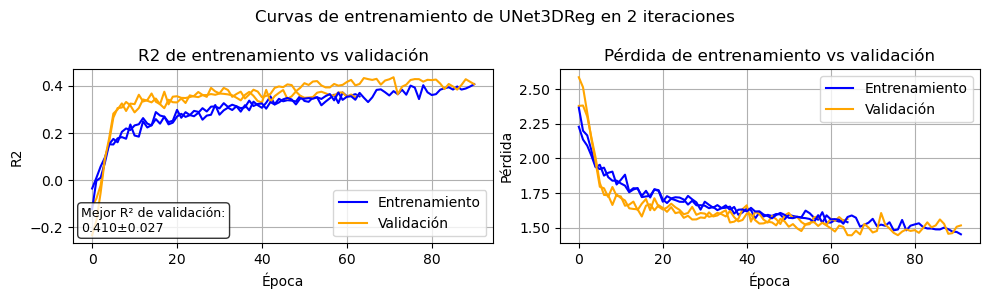

0

In [17]:

with open(filepath, "r") as file:
    data = json.load(file)
list_of_r2_train = data["list_of_r2_train"]
list_of_r2_val = data["list_of_r2_val"]
list_of_train_loss = data["list_of_train_loss"]
list_of_val_loss = data["list_of_val_loss"]
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
fig.suptitle(f"Curvas de entrenamiento de {model_name} en {iters} iteraciones", fontsize=12)
for i in range(len(list_of_r2_train) - 1):
    axes[0].plot(list_of_r2_train[i], color="blue")
    axes[0].plot(list_of_r2_val[i], color="orange")
axes[0].plot(list_of_r2_train[-1], color="blue", label="Entrenamiento")
axes[0].plot(list_of_r2_val[-1], color="orange", label="Validación")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("R2")
axes[0].set_title("R2 de entrenamiento vs validación")
axes[0].grid(True)
axes[0].legend()

for i in range(len(list_of_train_loss) - 1):
    axes[1].plot(list_of_train_loss[i], color="blue")
    axes[1].plot(list_of_val_loss[i], color="orange")
axes[1].plot(list_of_train_loss[-1], color="blue", label="Entrenamiento")
axes[1].plot(list_of_val_loss[-1], color="orange", label="Validación")



axes[1].set_xlabel("Época")
axes[1].set_ylabel("Pérdida")
axes[1].set_title("Pérdida de entrenamiento vs validación")
axes[1].grid(True)
axes[1].legend()

best_val_r2 = np.array([np.max(r2_curve) for r2_curve in list_of_r2_val])
mean_best_val_r2 = best_val_r2.mean()
std_best_val_r2 = best_val_r2.std()
# Text annotation inside the plot
axes[0].text(
    0.02,
    0.05,
    f"Mejor R² de validación:\n{mean_best_val_r2:.3f}±{std_best_val_r2:.3f}",
    transform=axes[0].transAxes,
    fontsize=9,
    verticalalignment="bottom",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

plt.tight_layout()
plt.show()

img_buffer1 = BytesIO()
fig.savefig(img_buffer1, format="png", bbox_inches="tight")
img_buffer1.seek(0)


In [18]:
def regression_metrics_dl(y_true, y_pred, mask_spatial):
    mask_bool = mask_spatial.astype(bool)

    # =====================================================
    # 1. PREPARE MASK
    # =====================================================
    if mask_bool.ndim == 2:
        mask_bool = np.broadcast_to(mask_bool, y_true.shape)
    elif mask_bool.ndim == 3:
        mask_bool = np.broadcast_to(mask_bool[:, None, :, :], y_true.shape)

    # =====================================================
    # 2. FLATTEN FOR GLOBAL METRICS
    # =====================================================
    y_true_flat = y_true.flatten()
    y_pred_flat = y_pred.flatten()
    mask_flat = mask_bool.flatten()

    y_test_masked = y_true_flat[mask_flat]
    y_pred_masked = y_pred_flat[mask_flat]

    # =====================================================
    # 3. REGRESSION METRICS
    # =====================================================
    rmse = np.sqrt(mean_squared_error(y_test_masked, y_pred_masked))
    mae = mean_absolute_error(y_test_masked, y_pred_masked)
    r2 = r2_score(y_test_masked, y_pred_masked)
    pearson_corr = pearsonr(y_test_masked, y_pred_masked)[0]
    mbe = np.mean(y_pred_masked - y_test_masked)

    data_range_flat = np.max(y_test_masked) - np.min(y_test_masked)
    nrmse = rmse / data_range_flat if data_range_flat > 0 else np.nan

    w_dist = wasserstein_distance(y_test_masked, y_pred_masked)
    spearman_corr, p_val = spearmanr(y_test_masked, y_pred_masked)

    # =====================================================
    # 4. MASKED SSIM
    # =====================================================
    data_range = 1.0
    ssim_scores = []

    for i in range(y_true.shape[0]):
        for h in range(y_true.shape[1]):
            _, ssim_map = ssim(y_true[i, h], y_pred[i, h], data_range=data_range, win_size=11, gaussian_weights=True, full=True)
            valid_ssim_pixels = ssim_map[mask_bool[i, h]]

            if len(valid_ssim_pixels) > 0:
                ssim_scores.append(np.mean(valid_ssim_pixels))

    mean_ssim = np.mean(ssim_scores)

    # =====================================================
    # 5. R2 BY PREDICTION HORIZON
    # =====================================================
    print("\nR2 by prediction horizon")

    for h in range(y_true.shape[1]):
        y_true_h = y_true[:, h][mask_bool[:, h]]
        y_pred_h = y_pred[:, h][mask_bool[:, h]]
        r2_h = r2_score(y_true_h, y_pred_h)
        print(f"Month +{h+1}: R² = {r2_h:.4f}")
        print(y_true_h.shape)
        print(y_pred_h.shape)

    print(f"\nOverall -> R2: {r2:.4f}, Pearson: {pearson_corr:.4f}, Spearman: {spearman_corr:.4f}, Mean Masked SSIM: {mean_ssim:.4f}")

    list_of_metrics = [r2, pearson_corr, mean_ssim, rmse, nrmse, mae, mbe, w_dist, spearman_corr]
    return list_of_metrics

In [19]:
columns = ["r2", "pearson_corr","mean_ssim", "rmse", "nrmse", "mae", "mbe", "w_dist", "spearman_corr"]
metrics_df = pd.DataFrame(columns=columns)

for i in range(iters):
    print(f"--------------------------------Iteration {i+1}/{iters}------------------------------------------------------------------------------------------------------")
    file = f"./modelos/runs/Regression/{model_name}_{sp}_{i+1}.pth"
    if todas:
        file = f"./modelos/runs/Regression/{model_name}_{sp}_{i+1}_todas.pth"
    model.load_state_dict(torch.load(file, map_location=device))
    model.to(device)
    model.eval()
    all_preds = []
    all_targets = []
    all_masks = []  

    with torch.no_grad():
        for x, y, m in test_loader:
            x = x.to(device)
            
            # Output shape: (B, horizon, H, W)
            pred = model(x)

            # Keep them raw; do not multiply by m here
            all_preds.append(pred.cpu().numpy())
            all_targets.append(y.cpu().numpy())
            all_masks.append(m.cpu().numpy())

    # Concatenate along the batch dimension (N, horizon, H, W)
    all_preds = np.concatenate(all_preds, axis=0)     
    all_targets = np.concatenate(all_targets, axis=0) 
    all_masks = np.concatenate(all_masks, axis=0)

    metrics = regression_metrics_dl(
        y_true=all_targets, 
        y_pred=all_preds, 
        mask_spatial=all_masks
    )
    metrics_df.loc[len(metrics_df)] = metrics




--------------------------------Iteration 1/2------------------------------------------------------------------------------------------------------

R2 by prediction horizon
Month +1: R² = 0.4223
(1500,)
(1500,)

Overall -> R2: 0.4223, Pearson: 0.6563, Spearman: 0.5670, Mean Masked SSIM: 0.1662
--------------------------------Iteration 2/2------------------------------------------------------------------------------------------------------

R2 by prediction horizon
Month +1: R² = 0.4230
(1500,)
(1500,)

Overall -> R2: 0.4230, Pearson: 0.6606, Spearman: 0.6562, Mean Masked SSIM: 0.1884


In [20]:
display(metrics_df)

metrics_summary_df = pd.DataFrame(
    {col: [f"{metrics_df[col].mean():.3f}±{metrics_df[col].std():.3f}"]for col in metrics_df.columns})

display(metrics_summary_df)

,r2,pearson_corr,mean_ssim,rmse,nrmse,mae,mbe,w_dist,spearman_corr
0,0.422293,0.656311,0.166172,1.347188,0.117155,0.734608,-0.129358,0.472252,0.56700
1,0.423035,0.660645,0.188430,1.346322,0.117079,0.712192,-0.149269,0.473913,0.65623


,r2,pearson_corr,mean_ssim,rmse,nrmse,mae,mbe,w_dist,spearman_corr
0,0.423±0.001,0.658±0.003,0.177±0.016,1.347±0.001,0.117±0.000,0.723±0.016,-0.139±0.014,0.473±0.001,0.612±0.063


In [21]:
def evaluate_with_zeroed_channel(model, loader, channel_to_zero, device):
    model.eval()
    
    total_loss = 0.0
    total_r2 = 0.0
    total_ssim = 0.0
    total_samples = 0

    with torch.no_grad():
        for x, y, m in loader:
            x = x.clone().to(device)
            y = y.to(device)
            m = m.to(device)
            
            batch_size = x.size(0)

            if isinstance(channel_to_zero, int):
                x[:, :, channel_to_zero, :, :] = 0
            if channel_to_zero ==  "all":
                x[:, :, :, :, :] = 0

            pred = model(x)
            loss = criterion(pred, y, m)
            pred_matched = pred.view_as(y)
            
            # --- GPU R2 Score (Mask-Aware) ---
            m_bool = m > 0.5
            y_true_flat = y[m_bool]
            y_pred_flat = pred_matched[m_bool]

            if y_true_flat.numel() > 1 and torch.var(y_true_flat) > 0:
                r2 = torch_r2_score(y_pred_flat, y_true_flat)
            else:
                r2 = torch.tensor(0.0, device=device)

            H, W = y.shape[-2], y.shape[-1]
            y_slices = y.reshape(-1, 1, H, W)
            pred_slices = pred.reshape(-1, 1, H, W)
            
            # Dynamic data range calculation on GPU
            data_range = torch.clamp(y_slices.max() - y_slices.min(), min=1e-5)
            
            ssim_val = structural_similarity_index_measure(
                pred_slices, y_slices, data_range=data_range
            )

            # Weight metrics by batch size for an exact dataset-wide average
            total_loss += loss.item() * batch_size
            total_r2 += r2.item() * batch_size
            total_ssim += ssim_val.item() * batch_size
            total_samples += batch_size

    return (
        total_loss / total_samples, 
        total_r2 / total_samples, 
        total_ssim / total_samples
    )


all_importances = []

for i in range(iters):
    #compute baseline
    file = f"./modelos/runs/Regression/{model_name}_{sp}_{i+1}.pth"
    if todas:
        file = f"./modelos/runs/Regression/{model_name}_{sp}_{i+1}_todas.pth"
    model.load_state_dict(torch.load(
        file,
        map_location=device
    ))
    model.to(device)

    baseline_loss, baseline_r2, baseline_ssim = evaluate_with_zeroed_channel(
        model, test_loader, channel_to_zero=None, device=device
    )

    loss_importances = []
    r2_importances = []
    ssim_importances = []

    features_names = data_builder.vars_names

    #compute importance for each channel
    for c in range(in_channels):
        loss, r2, ssim_val = evaluate_with_zeroed_channel(
            model, test_loader, channel_to_zero=c, device=device
        )

        loss_importances.append(loss - baseline_loss)
        r2_importances.append(baseline_r2 - r2)
        ssim_importances.append(baseline_ssim - ssim_val)

    df_importance = pd.DataFrame({
        "variable": features_names,
        "r2_importance": r2_importances,
        "ssim_importance": ssim_importances,
        "loss_importance": loss_importances,
    })

    df_importance["r2_drop_%"] = (
        df_importance["r2_importance"] / baseline_r2 * 100
    )

    all_importances.append(df_importance)

# Concatenate all model importances
all_df = pd.concat(all_importances, ignore_index=True)

# Compute mean and std for each variable
mean_df = all_df.groupby("variable").mean(numeric_only=True)
std_df = all_df.groupby("variable").std(numeric_only=True)

# Build "mean ± std" table
summary_df = pd.DataFrame(index=mean_df.index)

for col in mean_df.columns:
    summary_df[col] = [
        f"{m:.4f} ± {s:.4f}"
        for m, s in zip(mean_df[col], std_df[col])
    ]

# Sort using the numeric mean r2_importance
summary_df = summary_df.loc[
    mean_df["r2_importance"].sort_values(ascending=False).index
].reset_index()

display(summary_df)

,variable,r2_importance,ssim_importance,loss_importance,r2_drop_%
0,MCOS,0.1928 ± 0.1729,0.1226 ± 0.1012,0.3436 ± 0.4426,45.6293 ± 40.9636
1,UGO,0.0759 ± 0.0188,0.0053 ± 0.0045,0.1358 ± 0.0357,17.9600 ± 4.4642
2,TO,0.0580 ± 0.0878,0.0156 ± 0.0219,0.0996 ± 0.1688,13.7172 ± 20.7582
3,MSEN,0.0531 ± 0.0375,0.0468 ± 0.0690,0.0842 ± 0.0876,12.5638 ± 8.8911
4,MLOTST,0.0426 ± 0.0257,0.0283 ± 0.0223,0.0771 ± 0.0320,10.0754 ± 6.0885
5,VGO,0.0335 ± 0.0412,0.0013 ± 0.0034,0.0645 ± 0.0869,7.9206 ± 9.7360
6,TOB,0.0187 ± 0.0126,0.0096 ± 0.0117,0.0339 ± 0.0266,4.4120 ± 2.9653
7,SO,0.0113 ± 0.0025,-0.0156 ± 0.0008,0.0237 ± 0.0079,2.6807 ± 0.5871


In [22]:
# save everyhtng to a excel workbook
sheet_name = f"{model_name}_{sp}"
if todas: 
    sheet_name = f"{model_name}_{sp}_todas"
with pd.ExcelWriter("./modelos/resultados/Regre/DL_reg.xlsx", engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:
    metrics_summary_df.to_excel(writer, sheet_name=sheet_name, startrow=1, index=False)
with pd.ExcelWriter("./modelos/resultados/Regre/DL_reg.xlsx", engine="openpyxl", mode="a", if_sheet_exists="overlay") as writer:
    summary_df.to_excel(writer, sheet_name=sheet_name, startrow=len(metrics_summary_df) + 3, index=False)
    ws = writer.sheets[sheet_name]
    img1 = Image(img_buffer1)
    ws.add_image(img1, f"N1")